<a href="https://colab.research.google.com/github/siddhiware/Thiranex-data-analytics/blob/main/Thiranex_Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Libraries imported successfully!

Historical dataset created!
Number of records: 68

First 10 records:


,Date,Sales,Year,Month,Quarter,Month_Name
0,2021-01-01,108973.71,2021,1,1,January
1,2021-02-01,109354.14,2021,2,1,February
2,2021-03-01,118781.51,2021,3,1,March
3,2021-04-01,126244.49,2021,4,2,April
4,2021-05-01,110326.77,2021,5,2,May
5,2021-06-01,107126.90,2021,6,2,June
6,2021-07-01,118433.70,2021,7,3,July
7,2021-08-01,110079.22,2021,8,3,August
8,2021-09-01,100644.20,2021,9,3,September
9,2021-10-01,111880.23,2021,10,4,October



DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        68 non-null     datetime64[ns]
 1   Sales       68 non-null     float64       
 2   Year        68 non-null     int32         
 3   Month       68 non-null     int32         
 4   Quarter     68 non-null     int32         
 5   Month_Name  68 non-null     object        
dtypes: datetime64[ns](1), float64(1), int32(3), object(1)
memory usage: 2.5+ KB
None

Missing values:
Date          0
Sales         0
Year          0
Month         0
Quarter       0
Month_Name    0
dtype: int64

Duplicate rows:
0

DESCRIPTIVE STATISTICS


,Sales
count,68.000000
mean,159571.901618
std,36556.767891
min,100644.200000
25%,127061.277500
50%,158477.355000
75%,193088.890000
max,227849.920000


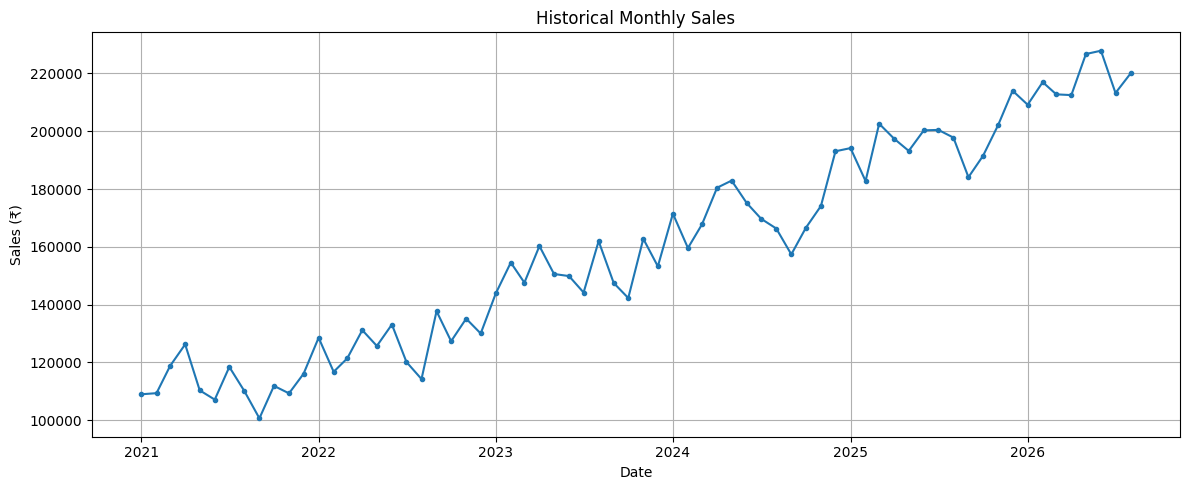


TRAIN TEST SPLIT
Training records: 54
Testing records: 14

Linear Regression model trained successfully!

MODEL PERFORMANCE
MAE  : ₹6,523.37
RMSE : ₹8,307.15
R² Score : 0.5391

ACTUAL VS PREDICTED SALES


,Date,Actual_Sales,Predicted_Sales,Error
0,2025-07-01,200448.00,193555.13,6892.87
1,2025-08-01,197789.99,194009.24,3780.75
2,2025-09-01,184086.26,194463.35,-10377.09
3,2025-10-01,191466.05,194502.54,-3036.49
4,2025-11-01,202050.11,194956.65,7093.46
5,2025-12-01,214004.36,195410.76,18593.60
6,2026-01-01,209166.61,212687.90,-3521.29
7,2026-02-01,216974.98,213142.02,3832.96
8,2026-03-01,212749.32,213596.13,-846.81
9,2026-04-01,212490.60,213635.32,-1144.72


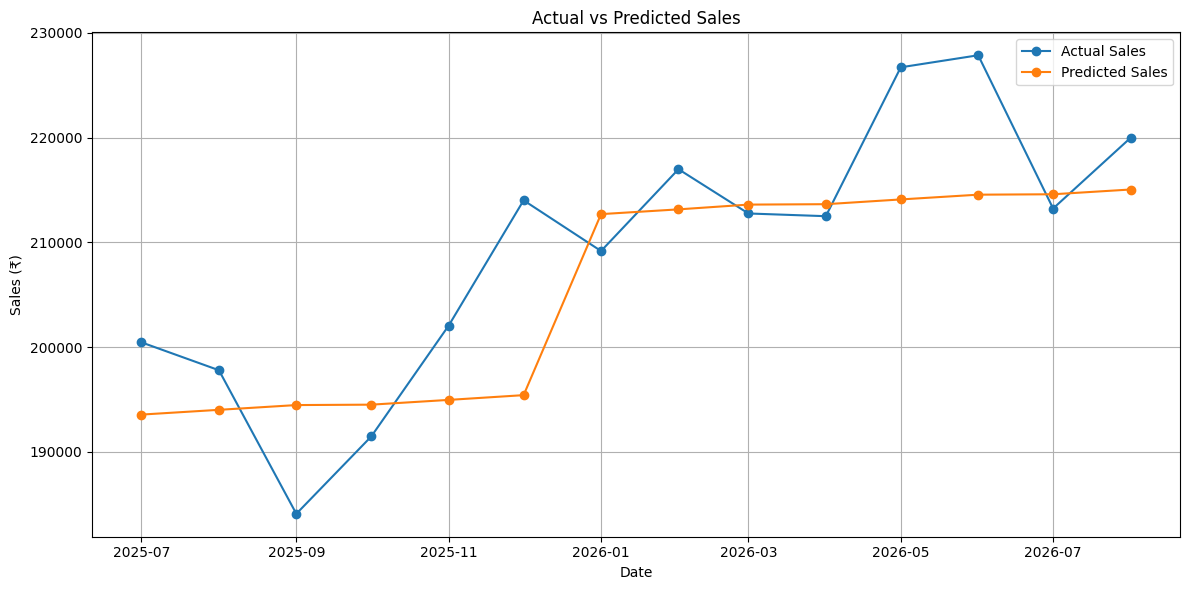


FUTURE SALES FORECAST


,Date,Month,Quarter,Time_Index,Predicted_Sales
0,2026-09-01,9,3,68,215490.96
1,2026-10-01,10,4,69,215530.15
2,2026-11-01,11,4,70,215984.26
3,2026-12-01,12,4,71,216438.37
4,2027-01-01,1,1,72,233715.51
5,2027-02-01,2,1,73,234169.62
6,2027-03-01,3,1,74,234623.74
7,2027-04-01,4,2,75,234662.93
8,2027-05-01,5,2,76,235117.04
9,2027-06-01,6,2,77,235571.15


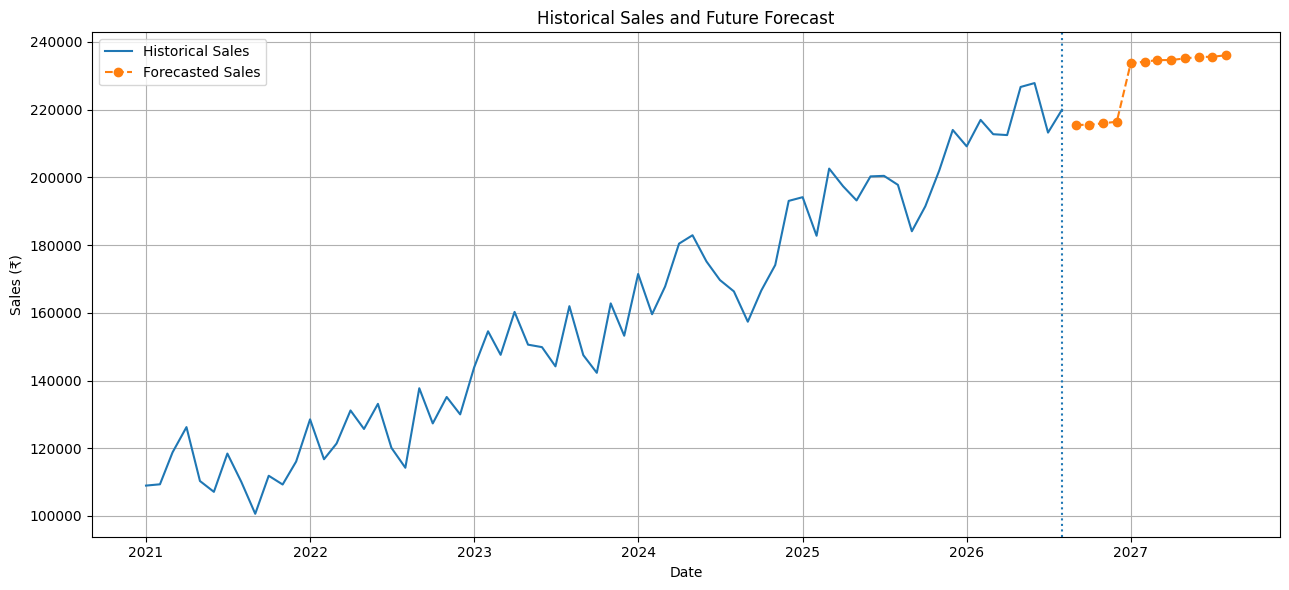


FORECAST SUMMARY
Total forecasted sales for next 12 months: ₹2,742,978.52
Average monthly forecast: ₹228,581.54
Highest forecasted month: ₹236,064.45
Lowest forecasted month: ₹215,490.96

MODEL COEFFICIENTS


,Feature,Coefficient
0,Time_Index,1752.300764
1,Month,-1298.189653
2,Quarter,-414.918097



BUSINESS INSIGHTS
1. Historical average monthly sales: ₹159,571.90
2. Forecast average monthly sales: ₹228,581.54
3. Forecasted change compared with historical average: 43.25%
4. The model's R² score is 0.5391, which indicates how much variation in the testing sales data is explained by the model.
5. The forecast can be used as a reference for future sales planning and trend analysis.

FILES CREATED
1. thiranex_historical_sales_data.csv
2. thiranex_actual_vs_predicted.csv
3. thiranex_future_sales_forecast.csv
4. thiranex_model_performance.csv
5. thiranex_predictive_analytics_complete.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

# ============================================================
# THIRANEX INTERNSHIP - TASK 3
# PREDICTIVE ANALYTICS USING HISTORICAL DATA
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from google.colab import files
from IPython.display import display

np.random.seed(42)

print("Libraries imported successfully!")


# ============================================================
# 2. CREATE HISTORICAL SALES DATASET
# ============================================================

# Monthly historical data
dates = pd.date_range(
    start="2021-01-01",
    end="2026-08-01",
    freq="MS"
)

n = len(dates)

# Create a realistic upward trend
trend = np.arange(n)

# Seasonal pattern
seasonality = (
    10000 * np.sin(
        2 * np.pi * dates.month / 12
    )
)

# Random variation
noise = np.random.normal(
    0,
    8000,
    n
)

# Generate sales
sales = (
    100000
    + trend * 1800
    + seasonality
    + noise
)

# Make sure sales are positive
sales = np.maximum(
    sales,
    20000
)

# Create dataset
df = pd.DataFrame({

    "Date": dates,

    "Sales": np.round(
        sales,
        2
    )

})


# ============================================================
# 3. ADD ADDITIONAL HISTORICAL FEATURES
# ============================================================

df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Quarter"] = (
    df["Date"].dt.quarter
)

df["Month_Name"] = (
    df["Date"].dt.month_name()
)


# ============================================================
# 4. SAVE ORIGINAL CSV
# ============================================================

original_file = (
    "thiranex_historical_sales_data.csv"
)

df.to_csv(
    original_file,
    index=False
)

print("\nHistorical dataset created!")

print(
    "Number of records:",
    len(df)
)

print("\nFirst 10 records:")

display(
    df.head(10)
)


# ============================================================
# 5. DATASET INFORMATION
# ============================================================

print("\n==============================")
print("DATASET INFORMATION")
print("==============================")

print(
    df.info()
)


# ============================================================
# 6. CHECK MISSING VALUES
# ============================================================

print("\nMissing values:")

print(
    df.isnull().sum()
)


# ============================================================
# 7. CHECK DUPLICATES
# ============================================================

print("\nDuplicate rows:")

print(
    df.duplicated().sum()
)


# Remove duplicates
df = df.drop_duplicates()


# ============================================================
# 8. DESCRIPTIVE STATISTICS
# ============================================================

print("\n==============================")
print("DESCRIPTIVE STATISTICS")
print("==============================")

display(
    df["Sales"].describe()
)


# ============================================================
# 9. VISUALIZE HISTORICAL SALES
# ============================================================

plt.figure(
    figsize=(12, 5)
)

plt.plot(
    df["Date"],
    df["Sales"],
    marker="o",
    markersize=3
)

plt.title(
    "Historical Monthly Sales"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Sales (₹)"
)

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 10. CREATE TIME FEATURES
# ============================================================

# Convert date into numerical time index

df["Time_Index"] = np.arange(
    len(df)
)


# ============================================================
# 11. PREPARE DATA FOR MACHINE LEARNING
# ============================================================

# Features
X = df[
    [
        "Time_Index",
        "Month",
        "Quarter"
    ]
]

# Target
y = df["Sales"]


# ============================================================
# 12. TRAIN-TEST SPLIT
# ============================================================

# For time-series data we should NOT randomly shuffle
# the data.

# Use first 80% for training
# Last 20% for testing

split_index = int(
    len(df) * 0.80
)

X_train = X.iloc[
    :split_index
]

X_test = X.iloc[
    split_index:
]

y_train = y.iloc[
    :split_index
]

y_test = y.iloc[
    split_index:
]


print("\n==============================")
print("TRAIN TEST SPLIT")
print("==============================")

print(
    "Training records:",
    len(X_train)
)

print(
    "Testing records:",
    len(X_test)
)


# ============================================================
# 13. TRAIN LINEAR REGRESSION MODEL
# ============================================================

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print(
    "\nLinear Regression model trained successfully!"
)


# ============================================================
# 14. PREDICT TEST DATA
# ============================================================

y_pred = model.predict(
    X_test
)


# ============================================================
# 15. MODEL EVALUATION
# ============================================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)


print("\n================================")
print("MODEL PERFORMANCE")
print("================================")

print(
    f"MAE  : ₹{mae:,.2f}"
)

print(
    f"RMSE : ₹{rmse:,.2f}"
)

print(
    f"R² Score : {r2:.4f}"
)


# ============================================================
# 16. CREATE ACTUAL VS PREDICTED DATAFRAME
# ============================================================

test_results = pd.DataFrame({

    "Date":
    df["Date"].iloc[
        split_index:
    ].values,

    "Actual_Sales":
    y_test.values,

    "Predicted_Sales":
    np.round(
        y_pred,
        2
    )

})


test_results[
    "Error"
] = (
    test_results["Actual_Sales"]
    -
    test_results["Predicted_Sales"]
)


print("\n==============================")
print("ACTUAL VS PREDICTED SALES")
print("==============================")

display(
    test_results.head(15)
)


# ============================================================
# 17. ACTUAL VS PREDICTED GRAPH
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    test_results["Date"],
    test_results["Actual_Sales"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    test_results["Date"],
    test_results["Predicted_Sales"],
    marker="o",
    label="Predicted Sales"
)

plt.title(
    "Actual vs Predicted Sales"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Sales (₹)"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 18. CREATE FUTURE DATES
# ============================================================

future_dates = pd.date_range(

    start=
    df["Date"].max()
    +
    pd.offsets.MonthBegin(1),

    periods=12,

    freq="MS"

)


# ============================================================
# 19. CREATE FUTURE FEATURES
# ============================================================

future_df = pd.DataFrame({

    "Date":
    future_dates

})

future_df["Month"] = (
    future_df["Date"].dt.month
)

future_df["Quarter"] = (
    future_df["Date"].dt.quarter
)

future_df["Time_Index"] = np.arange(

    len(df),

    len(df) + len(future_df)

)


# ============================================================
# 20. PREDICT FUTURE SALES
# ============================================================

future_X = future_df[
    [
        "Time_Index",
        "Month",
        "Quarter"
    ]
]

future_predictions = model.predict(
    future_X
)

future_df[
    "Predicted_Sales"
] = np.round(
    future_predictions,
    2
)


print("\n================================")
print("FUTURE SALES FORECAST")
print("================================")

display(
    future_df
)


# ============================================================
# 21. FUTURE SALES FORECAST GRAPH
# ============================================================

plt.figure(
    figsize=(13, 6)
)

# Historical data
plt.plot(

    df["Date"],

    df["Sales"],

    label="Historical Sales"

)

# Forecast
plt.plot(

    future_df["Date"],

    future_df["Predicted_Sales"],

    marker="o",

    linestyle="--",

    label="Forecasted Sales"

)

plt.axvline(

    df["Date"].max(),

    linestyle=":"

)

plt.title(
    "Historical Sales and Future Forecast"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Sales (₹)"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 22. FORECAST SUMMARY
# ============================================================

total_forecast = (
    future_df["Predicted_Sales"]
    .sum()
)

average_forecast = (
    future_df["Predicted_Sales"]
    .mean()
)

highest_forecast = (
    future_df["Predicted_Sales"]
    .max()
)

lowest_forecast = (
    future_df["Predicted_Sales"]
    .min()
)


print("\n==============================")
print("FORECAST SUMMARY")
print("==============================")

print(
    f"Total forecasted sales for next 12 months: "
    f"₹{total_forecast:,.2f}"
)

print(
    f"Average monthly forecast: "
    f"₹{average_forecast:,.2f}"
)

print(
    f"Highest forecasted month: "
    f"₹{highest_forecast:,.2f}"
)

print(
    f"Lowest forecasted month: "
    f"₹{lowest_forecast:,.2f}"
)


# ============================================================
# 23. MODEL COEFFICIENTS
# ============================================================

coefficients = pd.DataFrame({

    "Feature":
    X.columns,

    "Coefficient":
    model.coef_

})


print("\n==============================")
print("MODEL COEFFICIENTS")
print("==============================")

display(
    coefficients
)


# ============================================================
# 24. SAVE TEST PREDICTIONS
# ============================================================

test_file = (
    "thiranex_actual_vs_predicted.csv"
)

test_results.to_csv(

    test_file,

    index=False

)


# ============================================================
# 25. SAVE FUTURE FORECAST
# ============================================================

forecast_file = (
    "thiranex_future_sales_forecast.csv"
)

future_df.to_csv(

    forecast_file,

    index=False

)


# ============================================================
# 26. SAVE MODEL PERFORMANCE
# ============================================================

performance_file = (
    "thiranex_model_performance.csv"
)

performance_df = pd.DataFrame({

    "Metric": [
        "MAE",
        "RMSE",
        "R2 Score"
    ],

    "Value": [
        mae,
        rmse,
        r2
    ]

})

performance_df.to_csv(

    performance_file,

    index=False

)


# ============================================================
# 27. SAVE COMPLETE DATASET
# ============================================================

complete_file = (
    "thiranex_predictive_analytics_complete.csv"
)

df.to_csv(

    complete_file,

    index=False

)


# ============================================================
# 28. BUSINESS INSIGHTS
# ============================================================

historical_average = (
    df["Sales"].mean()
)

forecast_change = (

    (
        average_forecast
        -
        historical_average
    )
    /
    historical_average
) * 100


print("\n==========================================")
print("BUSINESS INSIGHTS")
print("==========================================")

print(
    f"1. Historical average monthly sales: "
    f"₹{historical_average:,.2f}"
)

print(
    f"2. Forecast average monthly sales: "
    f"₹{average_forecast:,.2f}"
)

print(
    f"3. Forecasted change compared with "
    f"historical average: {forecast_change:.2f}%"
)

print(
    f"4. The model's R² score is {r2:.4f}, "
    f"which indicates how much variation in the "
    f"testing sales data is explained by the model."
)

print(
    "5. The forecast can be used as a reference "
    "for future sales planning and trend analysis."
)


# ============================================================
# 29. DOWNLOAD IMPORTANT FILES
# ============================================================

print("\n==========================================")
print("FILES CREATED")
print("==========================================")

print(
    "1. thiranex_historical_sales_data.csv"
)

print(
    "2. thiranex_actual_vs_predicted.csv"
)

print(
    "3. thiranex_future_sales_forecast.csv"
)

print(
    "4. thiranex_model_performance.csv"
)

print(
    "5. thiranex_predictive_analytics_complete.csv"
)


# Download the main dataset
files.download(
    complete_file
)